# Credit Default Swap (CDS) Pricing

This notebook implements CDS pricing from first principles using QuantLib,
covering the full analytical framework used in production risk systems.

**Regulatory context:**
- FRTB SA -- Credit Spread Risk non-securitisation (CSR-NS), CRR3 Article 325
- IFRS 9 -- CDS as Level 2 fair value instruments
- EMIR -- CDS reporting and clearing obligations
- Basel IV -- counterparty credit risk (CVA for bilateral CDS)

**Contents:**
1. CDS mechanics and market conventions
2. Hazard rate and survival probability
3. Premium leg and protection leg valuation
4. Par spread and upfront pricing
5. CS01 -- credit spread sensitivity
6. Jump-to-default risk
7. CDS curve bootstrapping from market quotes
8. FRTB CSR-NS -- delta capital
9. MTM lifecycle -- seasoned CDS

In [13]:
from quant_risk.setup import base, asset_pricing

np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()

C1, C2, C3, C4 = '#2E75B6', '#ED7D31', '#A9D18E', '#C00000'
day_count = ql.Actual365Fixed()

base loaded
OISCurve | currency=EUR | valuation_date=2026-03-24
NSSCurve | currency=EUR | valuation_date=2026-05-27
Valuation date : March 24th, 2026
Calendar       : TARGET
asset pricing loaded


## 0. Basic Concepts

#### CDS spread / par spread
* Running coupon that would make the CDS NPV exactly zero at inception if you were free to set any coupon. 
* It is the market's price for the credit/default risk expressed as an annual rate.
* The credit/default risk is derived from the **harzard rate**: Implied probability of default per unity of time.
* No-arbitrage condition: bond_spread = CDS_spread.
* 40% recovery: a modelling assumption used for pricing and risk management.
* Recovery rate risk: mismatch between the assumed 40% and the actual ISDA auction recovery.





## 1. CDS Mechanics and Market Conventions

A Credit Default Swap transfers credit risk between two counterparties.
<small> 

| Party | Cash flows |
|-------|------------|
| Protection buyer | ±upfront at inception; -coupon × notional × dcf per period; +LGD on default |
| Protection seller | ∓upfront at inception; +coupon × notional × dcf per period; -LGD on default |

</small> 

<small><i>- LGD: loss given default</small></i>

<small><i>- dcf: day count fraction</small></i>


**ISDA market conventions (post-Big Bang 2009):**
<small> 

| Convention | Detail |
|------------|--------|
| Coupon | Standardised at 100bps (IG) or 500bps (HY) |
| Payment | Quarterly, 20th of March/June/September/December  |
| Day count | Actual/360 |
| Settlement | T+3, physical or cash settlement |
| Upfront | Paid at inception to compensate for standardised coupon vs par spread |
| Recovery | Market convention 40% for senior unsecured |

</small> 

**NOTE: IMM dates vs 20thIMM dates**
- IMM: International Monetary Market -- the futures exchange division of the Chicago Mercantile Exchange 
- IMM dates are the third Wednesday of March, June, September, and December
- 20thIMM dates or ISDA CDS are on the same month but on a fixed date 20th.

IMM dates were originally quarterly expiry dates set for CME futures contracts, becoming the standard roll dates across many OTC derivatives as interest rate swaps, and FX forwards because they allow netting and offsetting of positions across the market.


**Upfront payment:**

Since coupons are standardised, the difference between the par spread and the
standard coupon is settled upfront:

$$\text{Upfront} = (\text{ParSpread} - \text{Coupon}) \times \text{RiskyAnnuity}$$

A CDS trading at 150bps par spread with 100bps standard coupon requires
the protection buyer to pay 50bps × risky annuity upfront.

In [14]:
# ── OIS discount curve -- EUR flat at 2.5% ───────────────────────────────────
# In production: load from OISCurve bootstrapped from ECB MMSR
ois_rate    = 0.025
disc_curve  = ql.FlatForward(valuation_date, ois_rate, day_count)
disc_handle = ql.YieldTermStructureHandle(disc_curve)

print(f'OIS discount rate (flat): {ois_rate*100:.2f}%')
print(f'Discount factor 1Y: {disc_curve.discount(valuation_date + ql.Period(1, ql.Years)):.6f}')
print(f'Discount factor 5Y: {disc_curve.discount(valuation_date + ql.Period(5, ql.Years)):.6f}')

OIS discount rate (flat): 2.50%
Discount factor 1Y: 0.975310
Discount factor 5Y: 0.882436


## 2. Hazard Rate and Survival Probability

* CDS pricing requires a model for the probability of default over time.
* The standard reduced-form model uses the **hazard rate** $h(t)$ -- the
<span style="color:#d14;"><b>instantaneous conditional default intensity</span></b>:

$$\text{S}(t) = \mathbb{P}(\tau > t) = e^{-\int_0^t h(s)\,ds}$$

Under flat hazard rate $h$:

$$\text{S}(t) = \mathbb{P}(\tau > t) = e^{-h \cdot t}$$

**Notation:**
* $\tau$ (tau) -- a random variable
representing when the firm defaults. 

* $t$ -- a fixed evaluation horizon (e.g. 5 years).

* $\text{S}(t) = \mathbb{P}(\tau > t)$ -- **survival probability**: probability that default has not happened yet by time $t$.

* $\text{PD}(t) = 1 - \mathbb{P}(\tau > t)$ -- **cumulative default probability**: probability that default has happened
by time $t$. 


So at any horizon $t$:

$$\text{PD}(t) = 1 - \mathbb{P}(\tau > t) = 1 - e^{-h \cdot t}$$

The survival probability declines over time, the cumulative default
probability rises. **Both are fully determined by the hazard rate $h$**.

The relationship between hazard rate, par spread $s$, and recovery rate $R$:

$$h \approx \frac{s}{1 - R}$$

This is the credit triangle.
At 150bps spread and 40% recovery: $h = 0.015 / 0.60 = 2.5\%$ per year.
Note: The credit triangle is an approximation that assumes flat hazard rate and flat discount curve.

In [15]:
# ── reference entity -- EUR IG corporate ─────────────────────────────────────
par_spread = 0.0150   # 150bps -- typical EUR IG single name
recovery   = 0.40     # 40% -- ISDA senior unsecured convention
notional   = 10_000_000  # EUR 10M

# implied hazard rate from credit triangle
hazard_rate = par_spread / (1 - recovery)
print(f'Par spread:    {par_spread*10000:.0f}bps')
print(f'Recovery rate: {recovery*100:.0f}%')
print(f'Hazard rate:   {hazard_rate*10000:.1f}bps ({hazard_rate*100:.2f}% per year)')

# QuantLib flat hazard rate curve
hazard_quote  = ql.QuoteHandle(ql.SimpleQuote(hazard_rate))
hazard_curve  = ql.FlatHazardRate(valuation_date, hazard_quote, day_count)
hazard_handle = ql.DefaultProbabilityTermStructureHandle(hazard_curve)

# survival probabilities
tenors = [0.25, 0.5, 1, 2, 3, 4, 5, 7, 10]
print(f"\n{'Tenor':<8} {'Survival prob':>14} {'Default prob':>14} {'Hazard rate':>14}")
print('-' * 54)
for t in tenors:
    dt      = valuation_date + ql.Period(int(t * 365), ql.Days)
    surv    = hazard_curve.survivalProbability(dt)
    default = 1 - surv
    h       = hazard_curve.hazardRate(dt)
    print(f'{t:<8.2f} {surv:>14.6f} {default:>14.6f} {h*10000:>12.1f}bps')

Par spread:    150bps
Recovery rate: 40%
Hazard rate:   250.0bps (2.50% per year)

Tenor     Survival prob   Default prob    Hazard rate
------------------------------------------------------
0.25           0.993787       0.006213        250.0bps
0.50           0.987612       0.012388        250.0bps
1.00           0.975310       0.024690        250.0bps
2.00           0.951229       0.048771        250.0bps
3.00           0.927743       0.072257        250.0bps
4.00           0.904837       0.095163        250.0bps
5.00           0.882497       0.117503        250.0bps
7.00           0.839457       0.160543        250.0bps
10.00          0.778801       0.221199        250.0bps


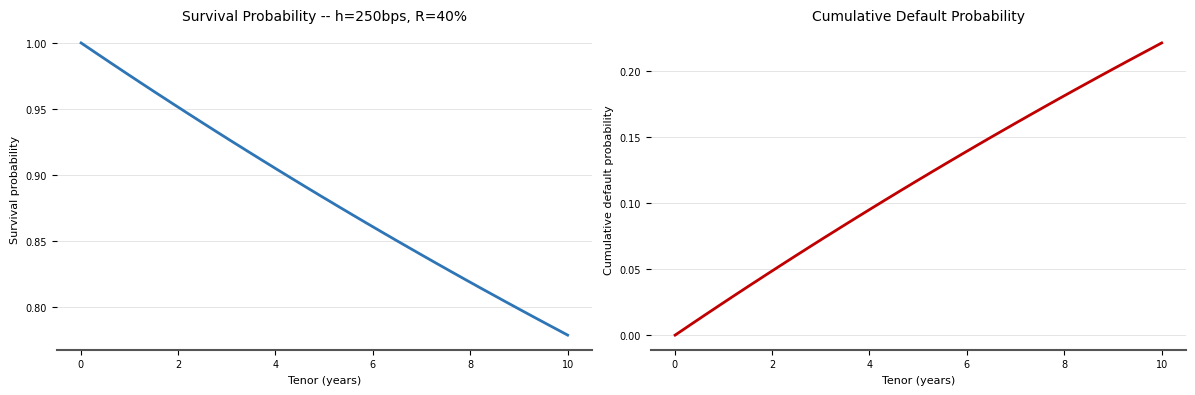

In [ ]:
# ── visualise survival probability curve ──────────────────────────────────────
t_range  = np.linspace(0.01, 10, 200)
surv_probs = [
    hazard_curve.survivalProbability(
        valuation_date + ql.Period(int(t * 365), ql.Days)
    ) for t in t_range
]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ax0.plot(t_range, surv_probs, color=C1, linewidth=2)
ax0.set_xlabel('Tenor (years)')
ax0.set_ylabel('Survival probability')
ax0.set_title(f'Survival Probability -- h={hazard_rate*10000:.0f}bps, R={recovery*100:.0f}%')
ax0.spines['bottom'].set_color('#555555')

ax1.plot(t_range, [1 - s for s in surv_probs], color=C4, linewidth=2)
ax1.set_xlabel('Tenor (years)')
ax1.set_ylabel('Cumulative default probability')
ax1.set_title('Cumulative Default Probability')
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 3. Premium Leg and Protection Leg Valuation

A CDS has two legs:

**Premium leg** -- the protection buyer pays a quarterly coupon:

$$\text{PV}_\text{premium} = s \cdot N \cdot \sum_{i=1}^{n} \delta_i \cdot \text{P}(0, t_i) \cdot \text{S}(0, t_i)$$

Where $\delta_i$ is the day count fraction, $\text{P}(0,t_i)$ is the OIS discount
factor, $\text{S}(0,t_i)$ is the survival probability and (below) R is recovery rate.

**Protection leg** -- the protection seller pays $(1-R) \times N$ on default:

$$\text{PV}_\text{protection} = (1-R) \cdot N \cdot \int_0^T \text{P}(0,t) \cdot (-d\text{S}(0,t))$$

**Par spread** -- the coupon that makes NPV zero at inception:

$$s^* = \frac{\text{PV}_\text{protection}}{\text{RiskyAnnuity}}$$

Where the risky annuity (PV01 or RPV01) is $\sum_i \delta_i \cdot \text{P}(0,t_i) \cdot \text{S}(0,t_i)$.

##### RPV01, CS01, IR PV01 -- Distinctions

**RPV01 (Risky PV01 / Risky Annuity)**
The present value of receiving 1 unit per year, weighted by both OIS discount
factors and survival probability:

$$\text{RPV01} = \sum_i \delta_i \cdot \text{P}(0,t_i) \cdot S(0,t_i)$$

An analytical quantity -- not a bump. Measures how much the premium leg is
worth per unit of spread. Stops paying on default -- hence "risky".

**CS01 -- Credit Spread Sensitivity**
Change in CDS NPV for a 1bp parallel shift in credit spread.
Computed from RPV01:

$$\text{CS01} = \text{RPV01} \times 0.0001 \times \text{Notional}$$

Or numerically -- bump all CDS spreads by 1bp, reprice, take the difference.
The dominant risk factor for CDS. Feeds into FRTB CSR-NS capital.

**IR PV01 -- Interest Rate Sensitivity**
Change in CDS NPV for a 1bp parallel shift in the OIS curve, holding
credit spread (survival probability) fixed.

Computed numerically only -- bump OIS curve by 1bp, reprice, take the difference.
Small relative to CS01 -- CDS is primarily a credit instrument.
Feeds into FRTB GIRR capital.

**Key distinction:** CS01 and IR PV01 are orthogonal sensitivities to
different risk factors -- credit spread and OIS rate respectively.
RPV01 is the analytical building block used to derive CS01, not a
sensitivity itself.

In [17]:
# ── build 5Y CDS -- protection buyer ─────────────────────────────────────────
maturity = ql.Date(20, 3, 2031)   # 5Y from March 2026 -- IMM date
coupon   = 0.0100                  # 100bps standard IG coupon

schedule = ql.Schedule(
    valuation_date, maturity,
    ql.Period(ql.Quarterly),
    calendar,
    ql.Following, ql.Unadjusted,
    ql.DateGeneration.TwentiethIMM, False  # ISDA IMM roll convention
)

cds = ql.CreditDefaultSwap(
    ql.Protection.Buyer,   # protection buyer perspective
    notional,              # EUR 10M
    coupon,                # 100bps standard coupon
    schedule,
    ql.Following,
    day_count
)

# MidPoint engine -- industry standard for CDS pricing
engine = ql.MidPointCdsEngine(hazard_handle, recovery, disc_handle)
cds.setPricingEngine(engine)

npv            = cds.NPV()
par_spread_ql  = cds.fairSpread()
premium_leg    = cds.couponLegNPV()
protection_leg = cds.defaultLegNPV()
pv01           = cds.couponLegBPS()   # value of 1bp on premium leg
risky_annuity  = -pv01 / 0.0001 / notional  # RPV01 per unit notional

print(f'CDS: {notional/1e6:.0f}M EUR 5Y | Coupon: {coupon*10000:.0f}bps | Par spread: {par_spread*10000:.0f}bps')
print(f'\nValuation (protection buyer perspective):')
print(f'  NPV:                   EUR {npv:>12,.2f}')
print(f'  Premium leg NPV:       EUR {premium_leg:>12,.2f}  (negative -- buyer pays)')
print(f'  Protection leg NPV:    EUR {protection_leg:>12,.2f}  (positive -- buyer receives on default)')
print(f'  Par spread (QL):       {par_spread_ql*10000:>10.2f}bps')
print(f'  PV01 (per 1bp):        EUR {pv01:>12,.2f}')
print(f'  Risky annuity (RPV01): {risky_annuity:>10.4f} years')
print(f'\nUpfront payment (par spread - coupon) × RPV01 × notional:')
upfront = (par_spread_ql - coupon) * risky_annuity * notional
print(f'  = ({par_spread_ql*10000:.1f}bps - {coupon*10000:.0f}bps) × {risky_annuity:.4f} × {notional/1e6:.0f}M')
print(f'  = EUR {upfront:,.2f}')

CDS: 10M EUR 5Y | Coupon: 100bps | Par spread: 150bps

Valuation (protection buyer perspective):
  NPV:                   EUR   222,267.79
  Premium leg NPV:       EUR  -440,377.96  (negative -- buyer pays)
  Protection leg NPV:    EUR   662,645.75  (positive -- buyer receives on default)
  Par spread (QL):           150.47bps
  PV01 (per 1bp):        EUR    -4,403.78
  Risky annuity (RPV01):     4.4038 years

Upfront payment (par spread - coupon) × RPV01 × notional:
  = (150.5bps - 100bps) × 4.4038 × 10M
  = EUR 222,267.79


## 4. Par Spread and Upfront Pricing

Post-ISDA Big Bang (2009), CDS trade with standardised coupons. The
difference between par spread and coupon is exchanged upfront.

**Points upfront (PUF):** market quoting convention -- the upfront as a
percentage of notional:

$$PUF = \frac{Upfront}{N} = (s^* - c) \times RPV01$$

Negative PUF means the protection buyer receives upfront (spread < coupon).
Positive PUF means the protection buyer pays upfront (spread > coupon).

In [18]:
# ── par spread vs upfront across spread levels ────────────────────────────────
spreads_bps = [50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500]
results     = []

for s_bps in spreads_bps:
    s      = s_bps / 10000
    h      = s / (1 - recovery)
    hq     = ql.QuoteHandle(ql.SimpleQuote(h))
    hc     = ql.FlatHazardRate(valuation_date, hq, day_count)
    hh     = ql.DefaultProbabilityTermStructureHandle(hc)

    cds_s  = ql.CreditDefaultSwap(
        ql.Protection.Buyer, notional, coupon, schedule, ql.Following, day_count
    )
    cds_s.setPricingEngine(ql.MidPointCdsEngine(hh, recovery, disc_handle))

    npv_s   = cds_s.NPV()
    puf     = npv_s / notional * 100   # points upfront as %
    pv01_s  = cds_s.couponLegBPS()
    ra      = -pv01_s / 0.0001 / notional

    results.append({
        'Par spread (bps)': s_bps,
        'Hazard rate (bps)': h * 10000,
        'NPV (EUR)': npv_s,
        'PUF (%)': puf,
        'RPV01': ra,
    })

df_puf = pd.DataFrame(results)
print('Par Spread vs Points Upfront (5Y CDS, 100bps coupon, EUR 10M):')
print(df_puf.to_string(index=False))

Par Spread vs Points Upfront (5Y CDS, 100bps coupon, EUR 10M):
 Par spread (bps)  Hazard rate (bps)      NPV (EUR)   PUF (%)    RPV01
               50          83.333333 -228491.381842 -2.284914 4.584243
               75         125.000000 -112384.407160 -1.123844 4.538199
              100         166.666667    1413.464862  0.014135 4.492780
              125         208.333333  112948.945010  1.129489 4.447977
              150         250.000000  222267.792578  2.222678 4.403780
              175         291.666667  329414.834823  3.294148 4.360179
              200         333.333333  434433.986010  4.344340 4.317165
              250         416.666667  638259.818903  6.382598 4.232865
              300         500.000000  834079.045205  8.340790 4.150809
              400         666.666667 1202965.975031 12.029660 3.993159
              500         833.333333 1543505.397163 15.435054 3.843701


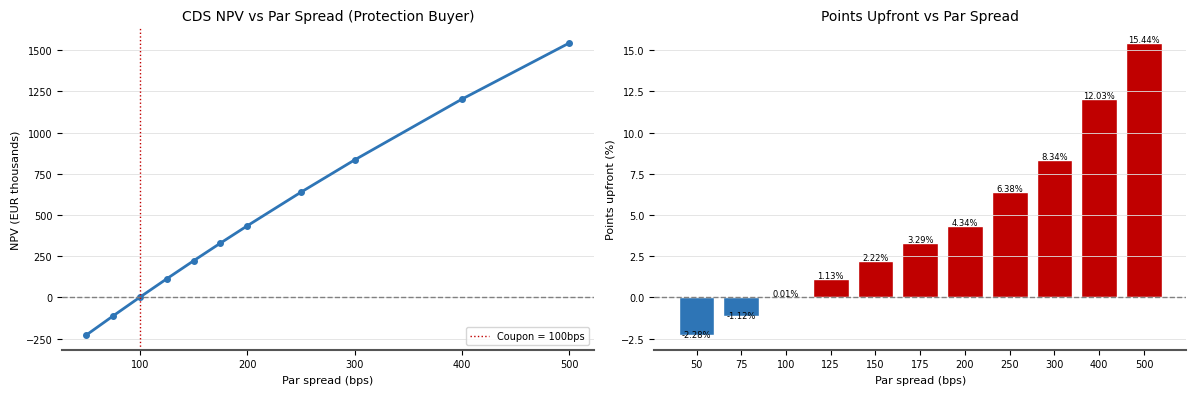

In [ ]:
# ── chart: NPV and PUF vs par spread ─────────────────────────────────────────
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ax0.plot(df_puf['Par spread (bps)'], df_puf['NPV (EUR)'] / 1000,
             color=C1, linewidth=2, marker='o', markersize=4)
ax0.axhline(0, color='grey', linestyle='--', linewidth=1)
ax0.axvline(100, color=C4, linestyle=':', linewidth=1, label='Coupon = 100bps')
ax0.set_xlabel('Par spread (bps)')
ax0.set_ylabel('NPV (EUR thousands)')
ax0.set_title('CDS NPV vs Par Spread (Protection Buyer)')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

ax1.bar(df_puf['Par spread (bps)'].astype(str), df_puf['PUF (%)'],
            color=[C4 if v > 0 else C1 for v in df_puf['PUF (%)']],
            edgecolor='white')
ax1.axhline(0, color='grey', linestyle='--', linewidth=1)
ax1.set_xlabel('Par spread (bps)')
ax1.set_ylabel('Points upfront (%)')
ax1.set_title('Points Upfront vs Par Spread')
ax1.spines['bottom'].set_color('#555555')
for i, (s, puf) in enumerate(zip(df_puf['Par spread (bps)'], df_puf['PUF (%)'])):
    ax1.text(i, puf + (0.05 if puf >= 0 else -0.12),
                 f'{puf:.2f}%', ha='center', fontsize=6)

plt.tight_layout()
plt.show()

## 5. CS01 -- Credit Spread Sensitivity

CS01 (also called DV01 or PVCS01) is the change in CDS NPV for a 1bp
parallel shift in the credit spread curve:

$$CS01 = \frac{\partial NPV}{\partial s} \cdot 0.0001$$

For a protection buyer, CS01 is positive -- when spreads widen (credit
deteriorates), the protection becomes more valuable.

**FRTB CSR-NS:** CS01 is the key sensitivity for FRTB credit spread risk
capital under CRR3 Article 325. Positions are bucketed by:
- Sector (corporates, sovereigns, covered bonds, ABS)
- Credit quality (IG vs HY)
- Tenor (0.5Y, 1Y, 2Y, 3Y, 5Y, 10Y)

Risk weights range from 0.5% (IG sovereigns) to 3% (HY corporates).

In [30]:
# ── CS01 -- the FOLLOWING REPRICING WILL BE DONE VIA ENGINE SWITCH  ────────────────────────────────────────────────────
# resusing the cds created above -- just update the pricing engine with the base hazard curve

bump = 0.0001   # 1bp

# base NPV
#---------------------------------------------------------------------------------------------
haz_base    = par_spread / (1 - recovery)

# hazard curve base -- flat hazard rate from credit triangle
curve_base   = ql.FlatHazardRate(
    valuation_date,
    ql.QuoteHandle(ql.SimpleQuote(haz_base)), 
    day_count
    )

engine_base = ql.MidPointCdsEngine(
    ql.DefaultProbabilityTermStructureHandle(curve_base), # curve_handle_base
    recovery, 
    disc_handle
    )

cds.setPricingEngine(engine_base)
npv_base  = cds.NPV()

# bumped NPV -- spread up 1bp
#---------------------------------------------------------------------------------------------
haz_up = (par_spread + bump) / (1 - recovery)

# hazard curve up
curve_up  = ql.FlatHazardRate(
    valuation_date,
    ql.QuoteHandle(ql.SimpleQuote(haz_up)), 
    day_count
    )

engine_up = ql.MidPointCdsEngine(
    ql.DefaultProbabilityTermStructureHandle(curve_up), # curve_handle_up
    recovery, 
    disc_handle
    )

cds.setPricingEngine(engine_up)
npv_up = cds.NPV()

cs01_numerical = npv_up - npv_base

RW_IG_5Y_BPS = 50  # 50bp risk weight for EUR IG 5Y

print(f'CS01 -- 5Y CDS EUR {notional/1e6:.0f}M, spread {par_spread*10000:.0f}bps:')
print(f'CS01 (credit spread 1bp bump): EUR {cs01_numerical:,.2f}')
print(f'\nFRTB CSR-NS context:')
print(f'  Risk weight (EUR IG 5Y): {RW_IG_5Y_BPS:.0f}bps')
print(f'  Weighted sensitivity:    EUR {cs01_numerical * RW_IG_5Y_BPS/10000:,.2f}')  # 50bp RW
print(f"Single-name CSR-NS input (CS01 × risk weight): EUR {cs01_numerical * RW_IG_5Y_BPS / 10000:,.2f}")


CS01 -- 5Y CDS EUR 10M, spread 150bps:
CS01 (credit spread 1bp bump): EUR 4,327.29

FRTB CSR-NS context:
  Risk weight (EUR IG 5Y): 50bps
  Weighted sensitivity:    EUR 21.64
Single-name CSR-NS input (CS01 × risk weight): EUR 21.64


In [ ]:
# ── CS01 across tenors ────────────────────────────────────────────────────────
frtb_tenors = {
    '0.5Y': (ql.Date(20, 9, 2026), 0.5),
    '1Y':   (ql.Date(20, 3, 2027), 1.0),
    '2Y':   (ql.Date(20, 3, 2028), 2.0),
    '3Y':   (ql.Date(20, 3, 2029), 3.0),
    '5Y':   (ql.Date(20, 3, 2031), 5.0),
    '10Y':  (ql.Date(20, 3, 2036), 10.0),
}

cs01_by_tenor = []

for label, (mat, t) in frtb_tenors.items():
    sched = ql.Schedule(
        valuation_date, mat,
        ql.Period(ql.Quarterly), calendar,
        ql.Following, ql.Unadjusted,
        ql.DateGeneration.TwentiethIMM, False
    )
    c_base = ql.CreditDefaultSwap(
        ql.Protection.Buyer, notional, coupon, sched, ql.Following, day_count
    )
    c_base.setPricingEngine(ql.MidPointCdsEngine(hh_base, recovery, disc_handle))

    c_up = ql.CreditDefaultSwap(
        ql.Protection.Buyer, notional, coupon, sched, ql.Following, day_count
    )
    c_up.setPricingEngine(ql.MidPointCdsEngine(hh_up, recovery, disc_handle))

    cs01 = c_up.NPV() - c_base.NPV()
    # FRTB CSR-NS risk weight -- IG corporate, tenor bucket
    rw = 0.005 if t <= 1 else (0.004 if t <= 3 else 0.003)

    cs01_by_tenor.append({
        'Tenor': label,
        'CS01 (EUR)': cs01,
        'FRTB RW': f'{rw*100:.1f}%',
        'Weighted sensitivity (EUR)': cs01 * rw / 0.0001,
    })

df_cs01 = pd.DataFrame(cs01_by_tenor)
print('CS01 and FRTB CSR-NS Weighted Sensitivity by Tenor:')
print(df_cs01.to_string(index=False))

CS01 and FRTB CSR-NS Weighted Sensitivity by Tenor:
Tenor  CS01 (EUR) FRTB RW  Weighted sensitivity (EUR)
 0.5Y  486.100311    0.5%                24305.015546
   1Y  960.982101    0.5%                48049.105041
   2Y 1879.997010    0.4%                75199.880410
   3Y 2744.166013    0.4%               109766.640525
   5Y 4327.285106    0.3%               129818.553183
  10Y 7559.550239    0.3%               226786.507167


## 6. Jump-to-Default Risk

Beyond spread sensitivity, CDS carry **jump-to-default (JTD)** risk --
the discontinuous P&L if the reference entity defaults immediately.

For a protection buyer:

$$JTD = (1 - R) \times N - PV_{premium\,leg}$$

The protection buyer receives LGD but loses the remaining premium stream.
Net JTD is positive for the buyer -- default is a gain event.

Under FRTB, JTD feeds into the **Default Risk Charge (DRC)** for the
trading book -- a separate capital component from the sensitivity-based method.

In [ ]:
# ── jump-to-default ───────────────────────────────────────────────────────────
lgd             = (1 - recovery) * notional   # loss given default
pv_premium_remaining = abs(premium_leg)       # PV of remaining premium payments

jtd_buyer  = lgd - pv_premium_remaining      # protection buyer: receive LGD, lose premium
jtd_seller = -lgd + pv_premium_remaining     # protection seller: pay LGD, keep premium

print(f'Jump-to-Default Analysis -- 5Y CDS EUR {notional/1e6:.0f}M:')
print(f'  Notional:                    EUR {notional:>12,.0f}')
print(f'  Recovery ({recovery*100:.0f}%):            EUR {recovery*notional:>12,.0f}')
print(f'  LGD ({(1-recovery)*100:.0f}%):                EUR {lgd:>12,.0f}')
print(f'  PV remaining premium:        EUR {pv_premium_remaining:>12,.0f}')
print(f'\n  JTD -- protection buyer:     EUR {jtd_buyer:>12,.0f}  (gain on default)')
print(f'  JTD -- protection seller:    EUR {jtd_seller:>12,.0f}  (loss on default)')
print(f'\nFRTB Default Risk Charge (DRC):')
print(f'  Gross JTD buyer:   EUR {max(jtd_buyer, 0):>12,.0f}')
print(f'  Gross JTD seller:  EUR {max(-jtd_seller, 0):>12,.0f}')

Jump-to-Default Analysis -- 5Y CDS EUR 10M:
  Notional:                    EUR   10,000,000
  Recovery (40%):            EUR    4,000,000
  LGD (60%):                EUR    6,000,000
  PV remaining premium:        EUR      440,378

  JTD -- protection buyer:     EUR    5,559,622  (gain on default)
  JTD -- protection seller:    EUR   -5,559,622  (loss on default)

FRTB Default Risk Charge (DRC):
  Gross JTD buyer:   EUR    5,559,622
  Gross JTD seller:  EUR    5,559,622


## 7. CDS Curve Bootstrapping from Market Quotes

In practice, hazard rates are not flat -- they are bootstrapped from
market CDS quotes at standard tenors (1Y, 2Y, 3Y, 5Y, 7Y, 10Y).

The bootstrapping procedure:
1. Start at the shortest tenor -- solve for the hazard rate that prices the 1Y CDS at par
2. Move to the next tenor -- holding the short hazard rate fixed, solve for the next segment
3. Repeat to build a piecewise flat hazard rate curve

QuantLib `PiecewiseFlatHazardRate` does this automatically.

In [9]:
# ── market CDS quotes -- EUR IG single name (upward sloping credit curve) ─────
market_tenors  = [1, 2, 3, 5, 7, 10]
market_spreads = [0.0080, 0.0110, 0.0130, 0.0150, 0.0165, 0.0180]  # bps: 80,110,130,150,165,180

# build helpers for bootstrapping
helpers = []
for t, s in zip(market_tenors, market_spreads):
    mat    = calendar.advance(valuation_date, ql.Period(t, ql.Years))
    helper = ql.SpreadCdsHelper(
        ql.QuoteHandle(ql.SimpleQuote(s)),
        ql.Period(t, ql.Years),
        0,              # settlement days
        calendar,
        ql.Quarterly,
        ql.Following,
        ql.DateGeneration.TwentiethIMM,
        day_count,
        recovery,
        disc_handle,
    )
    helpers.append(helper)

# bootstrap piecewise flat hazard rate curve
bootstrapped_curve = ql.PiecewiseFlatHazardRate(
    valuation_date, helpers, day_count
)
bootstrapped_curve.enableExtrapolation()
boot_handle = ql.DefaultProbabilityTermStructureHandle(bootstrapped_curve)

# display bootstrapped hazard rates and survival probabilities
print(f"{'Tenor':<8} {'Market spread':>14} {'Hazard rate':>14} {'Survival prob':>14}")
print('-' * 54)
for t, s in zip(market_tenors, market_spreads):
    dt      = valuation_date + ql.Period(int(t * 365), ql.Days)
    h       = bootstrapped_curve.hazardRate(dt)
    surv    = bootstrapped_curve.survivalProbability(dt)
    print(f'{t}Y{"":5} {s*10000:>12.1f}bps {h*10000:>12.1f}bps {surv:>14.6f}')

Tenor     Market spread    Hazard rate  Survival prob
------------------------------------------------------
1Y              80.0bps        132.6bps       0.986826
2Y             110.0bps        247.7bps       0.965388
3Y             130.0bps        296.6bps       0.938293
5Y             150.0bps        311.1bps       0.882007
7Y             165.0bps        354.1bps       0.822560
10Y             180.0bps        380.7bps       0.734256


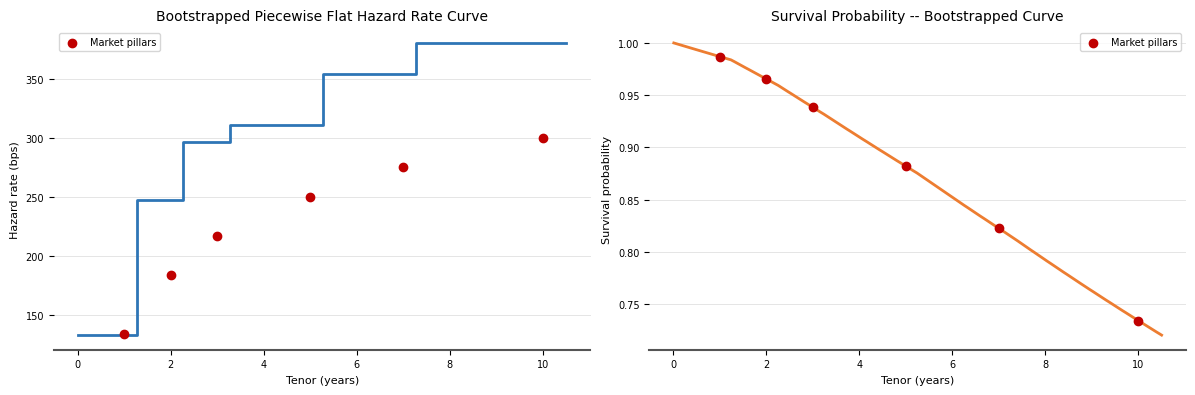

In [ ]:
# ── visualise bootstrapped curve ──────────────────────────────────────────────
t_range = np.linspace(0.01, 10.5, 300)

hazard_rates_boot = [
    bootstrapped_curve.hazardRate(
        valuation_date + ql.Period(int(t * 365), ql.Days)
    ) * 10000 for t in t_range
]
surv_boot = [
    bootstrapped_curve.survivalProbability(
        valuation_date + ql.Period(int(t * 365), ql.Days)
    ) for t in t_range
]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ax0.step(t_range, hazard_rates_boot, color=C1, linewidth=2, where='post')
ax0.scatter(market_tenors, [s / (1-recovery) * 10000 for s in market_spreads],
                color=C4, zorder=5, label='Market pillars')
ax0.set_xlabel('Tenor (years)')
ax0.set_ylabel('Hazard rate (bps)')
ax0.set_title('Bootstrapped Piecewise Flat Hazard Rate Curve')
ax0.legend()
ax0.spines['bottom'].set_color('#555555')

ax1.plot(t_range, surv_boot, color=C2, linewidth=2)
ax1.scatter(market_tenors,
    [bootstrapped_curve.survivalProbability(
        valuation_date + ql.Period(int(t*365), ql.Days)
     ) for t in market_tenors],
    color=C4, zorder=5, label='Market pillars')
ax1.set_xlabel('Tenor (years)')
ax1.set_ylabel('Survival probability')
ax1.set_title('Survival Probability -- Bootstrapped Curve')
ax1.legend()
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 8. FRTB CSR-NS -- Delta Capital

Under CRR3 / FRTB SA, CDS positions fall under **Credit Spread Risk
non-securitisation (CSR-NS)**.

**Delta sensitivities:** CS01 per tenor vertex (0.5Y, 1Y, 2Y, 3Y, 5Y, 10Y)

**Risk weights (EUR IG corporate, bucket 3):**
<small> 

| Tenor | Risk weight |
|-------|------------|
| 0.5Y | 0.5% |
| 1Y | 0.5% |
| 2Y | 0.5% |
| 3Y | 0.5% |
| 5Y | 0.5% |
| 10Y | 0.5% |

</small> 

**Aggregation:** within-bucket correlation $\rho = e^{-0.05 \times |t_i - t_j|}$,
then across buckets with prescribed inter-bucket correlations.

$$K_{bucket} = \sqrt{\sum_i WS_i^2 + \sum_{i \neq j} \rho_{ij} \cdot WS_i \cdot WS_j}$$

In [11]:
# ── FRTB CSR-NS delta capital for our CDS position ───────────────────────────
frtb_vertices = {
    '0.5Y': 0.5,
    '1Y':   1.0,
    '2Y':   2.0,
    '3Y':   3.0,
    '5Y':   5.0,
    '10Y':  10.0,
}

RW_IG = 0.005   # 0.5% risk weight -- IG corporate bucket

# compute CS01 at each FRTB vertex using bootstrapped curve
ws_list  = []   # weighted sensitivities
t_list   = []

for label, t in frtb_vertices.items():
    mat   = ql.Date(20, 3, int(2026 + t)) if t >= 1 else ql.Date(20, 9, 2026)
    sched = ql.Schedule(
        valuation_date, mat,
        ql.Period(ql.Quarterly), calendar,
        ql.Following, ql.Unadjusted,
        ql.DateGeneration.TwentiethIMM, False
    )

    # base
    c_b = ql.CreditDefaultSwap(
        ql.Protection.Buyer, notional, coupon, sched, ql.Following, day_count
    )
    c_b.setPricingEngine(ql.MidPointCdsEngine(boot_handle, recovery, disc_handle))

    # bumped hazard curve -- shift all hazard rates by 1bp equivalent
    helpers_up = []
    for t2, s2 in zip(market_tenors, market_spreads):
        helper_up = ql.SpreadCdsHelper(
            ql.QuoteHandle(ql.SimpleQuote(s2 + 0.0001)),
            ql.Period(t2, ql.Years), 0, calendar,
            ql.Quarterly, ql.Following,
            ql.DateGeneration.TwentiethIMM, day_count,
            recovery, disc_handle,
        )
        helpers_up.append(helper_up)
    bc_up = ql.PiecewiseFlatHazardRate(valuation_date, helpers_up, day_count)
    bc_up.enableExtrapolation()
    bh_up = ql.DefaultProbabilityTermStructureHandle(bc_up)

    c_u = ql.CreditDefaultSwap(
        ql.Protection.Buyer, notional, coupon, sched, ql.Following, day_count
    )
    c_u.setPricingEngine(ql.MidPointCdsEngine(bh_up, recovery, disc_handle))

    cs01  = c_u.NPV() - c_b.NPV()
    ws    = RW_IG * cs01 / 0.0001   # weighted sensitivity
    ws_list.append(ws)
    t_list.append(t)
    print(f'{label:<6} CS01: EUR {cs01:>8,.2f}  WS: EUR {ws:>10,.2f}')

# intra-bucket aggregation
ws_arr = np.array(ws_list)
t_arr  = np.array(t_list)
n      = len(ws_arr)
rho    = np.array([[np.exp(-0.05 * abs(t_arr[i] - t_arr[j])) for j in range(n)] for i in range(n)])
np.fill_diagonal(rho, 1.0)

K = np.sqrt(max(0, ws_arr @ rho @ ws_arr))
print(f'\nFRTB CSR-NS Delta Capital (single bucket): EUR {K:,.2f}')

0.5Y   CS01: EUR   486.26  WS: EUR  24,312.95
1Y     CS01: EUR   966.85  WS: EUR  48,342.52
2Y     CS01: EUR 1,904.12  WS: EUR  95,206.12
3Y     CS01: EUR 2,779.74  WS: EUR 138,987.03
5Y     CS01: EUR 4,353.82  WS: EUR 217,690.96
10Y    CS01: EUR 7,316.39  WS: EUR 365,819.46

FRTB CSR-NS Delta Capital (single bucket): EUR 814,423.79


## 9. MTM Lifecycle -- Seasoned CDS

A CDS entered into in the past has a non-zero MTM as credit spreads
have moved since inception. We simulate a seasoned 5Y CDS -- originally
struck at 150bps 1 year ago, now with 4Y remaining as spreads have moved.

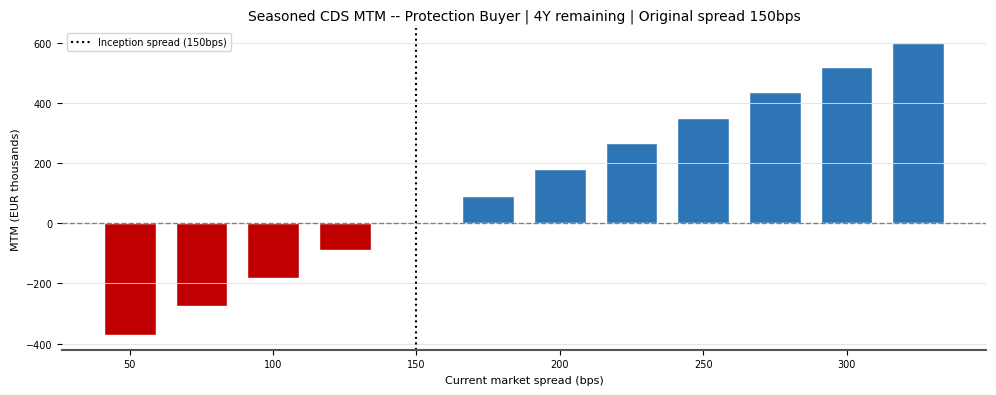

MTM > 0: spreads widened, protection more valuable (buyer gains)
MTM < 0: spreads tightened, protection less valuable (buyer loses)


In [12]:
# ── MTM lifecycle -- spread moves and time decay ──────────────────────────────
F0_spread     = 0.0150   # original par spread at inception
spread_moves  = np.arange(50, 350, 25)   # current market spreads in bps

mtm_values = []
for s_curr_bps in spread_moves:
    s_curr = s_curr_bps / 10000
    h_curr = s_curr / (1 - recovery)
    hc_c   = ql.FlatHazardRate(valuation_date,
                ql.QuoteHandle(ql.SimpleQuote(h_curr)), day_count)
    hh_c   = ql.DefaultProbabilityTermStructureHandle(hc_c)

    # 4Y remaining (original 5Y CDS, 1Y seasoned)
    mat_4y  = ql.Date(20, 3, 2030)
    sched_4y = ql.Schedule(
        valuation_date, mat_4y,
        ql.Period(ql.Quarterly), calendar,
        ql.Following, ql.Unadjusted,
        ql.DateGeneration.TwentiethIMM, False
    )
    cds_s = ql.CreditDefaultSwap(
        ql.Protection.Buyer, notional, F0_spread,  # original coupon = par spread at inception
        sched_4y, ql.Following, day_count
    )
    cds_s.setPricingEngine(ql.MidPointCdsEngine(hh_c, recovery, disc_handle))
    mtm_values.append(cds_s.NPV())

fig, ax = plt.subplots(figsize=(10, 4))
colors  = [C4 if v < 0 else C1 for v in mtm_values]
ax.bar(spread_moves, [v/1000 for v in mtm_values], color=colors,
       edgecolor='white', width=18)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.axvline(F0_spread * 10000, color='black', linestyle=':', linewidth=1.5,
           label=f'Inception spread ({F0_spread*10000:.0f}bps)')
ax.set_xlabel('Current market spread (bps)')
ax.set_ylabel('MTM (EUR thousands)')
ax.set_title('Seasoned CDS MTM -- Protection Buyer | 4Y remaining | Original spread 150bps')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

print('MTM > 0: spreads widened, protection more valuable (buyer gains)')
print('MTM < 0: spreads tightened, protection less valuable (buyer loses)')

#### iTraxx

iTraxx is the family of standardised CDS index products covering European, Asian,
and emerging market credit. The most relevant for EUR credit:

- **iTraxx Main** -- 125 IG European corporate names, equally weighted. Benchmark
  for European IG credit. 5Y most liquid, 100bps standard coupon.
- **iTraxx Crossover** -- 75 HY European names. Benchmark for European HY credit
  sentiment. 500bps standard coupon.
- **iTraxx Senior Financials** -- 25 senior unsecured European bank and insurer names.
  Closely watched during banking stress -- 2008, 2011 sovereign crisis, 2023 Credit Suisse.
- **iTraxx Subordinated Financials** -- same names, subordinated debt. Much wider
  than senior, reflects AT1/Tier 2 risk.

**Series and rolls:** iTraxx rolls every 6 months (March and September). Each roll
updates constituents -- names downgraded below IG drop out of Main, potentially
entering Crossover. On-the-run series is most liquid; off-the-run trades at a basis.

**Administered by** IHS Markit (now S&P Global) -- constituents, rolls, reference data.

**Why it matters:**
- Most liquid credit instrument in Europe -- EUR 500M tradeable in one ticket
- Real-time credit sentiment indicator across the market
- Hedging tool -- banks buy iTraxx protection to hedge loan book systemic credit risk
- Basis trade -- long single name CDS, short iTraxx
- Correlation product -- underlying for CDO tranches and structured credit

## Summary
<small> 

| Concept | Key result | Regulatory reference |
|---------|-----------|---------------------|
| Credit triangle | $h = s / (1-R)$ -- hazard rate from spread and recovery | Reduced-form model foundation |
| Premium leg | Risky annuity -- discounts by OIS and survival probability | EMIR OIS discounting |
| Protection leg | Expected LGD -- integrates default density against OIS | Basel IV CVA |
| Par spread | Equates NPV to zero at inception | ISDA standard |
| Upfront / PUF | $(s^* - c) \times RPV01$ -- post-Big Bang convention | ISDA 2009 |
| CS01 | 1bp parallel shift in credit curve | FRTB CSR-NS delta |
| Jump-to-default | LGD - PV(premium) -- discontinuous default event | FRTB Default Risk Charge |
| Curve bootstrapping | PiecewiseFlatHazardRate from market quotes | Production standard |
| FRTB CSR-NS capital | Intra-bucket aggregation with tenor correlations | CRR3 Article 325 |

</small> 

---
*Notebook QRE-69 | Sprint 5 | Quant Risk Engine*  
*Regulation: CRR3 (EU 2024/1623) FRTB CSR-NS, EMIR (EU 648/2012), IFRS 9/13*